In [45]:
import logging, warnings
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import spearmanr, ConstantInputWarning
from tqdm import tqdm
from umap import UMAP
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib
import importlib
import tqdm

import src.generate
importlib.reload(src.generate)
from src.generate import generate_mts_master

from src.utils import iter_dataset_dirs, load_json
from src.plot_style import apply_plot_style
from src.visualization import plot_mts_corr_density, plot_spi_space_individual, plot_spi_space_recursive
from src.generate import generate_mts_master

apply_plot_style()
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
warnings.simplefilter("ignore", ConstantInputWarning)

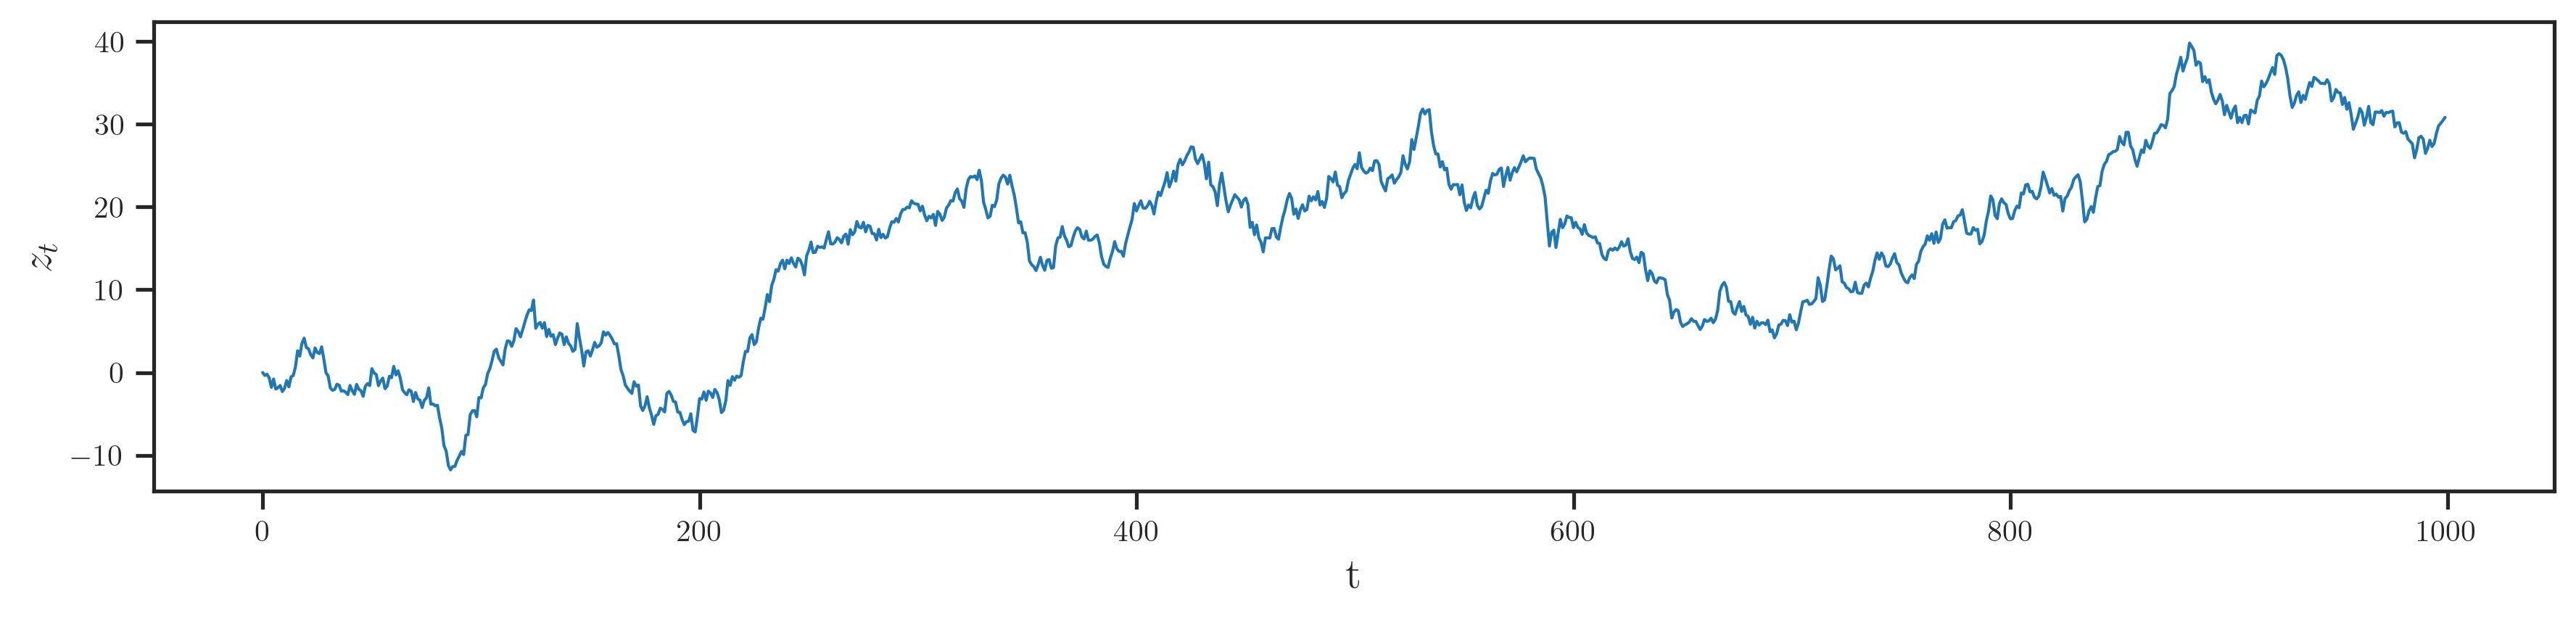

In [ ]:
def generate_ar1(T: int, a: float, noise_std: float, seed=None):
    rng = np.random.default_rng(seed)
    X = np.zeros(T)
    for t in range(1, T):
        X[t] = a * X[t-1] + rng.normal(0, noise_std)
    return X

z = generate_ar1(T=1000, a=1, noise_std=1.0, seed=110305)

fig, ax = plt.subplots(figsize=(12, 3), dpi=300)
ax.plot(z, lw=1.0, color="#1f77b4")
# ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel("t")
ax.set_ylabel("$z_t$")
fig.tight_layout()
plt.show()

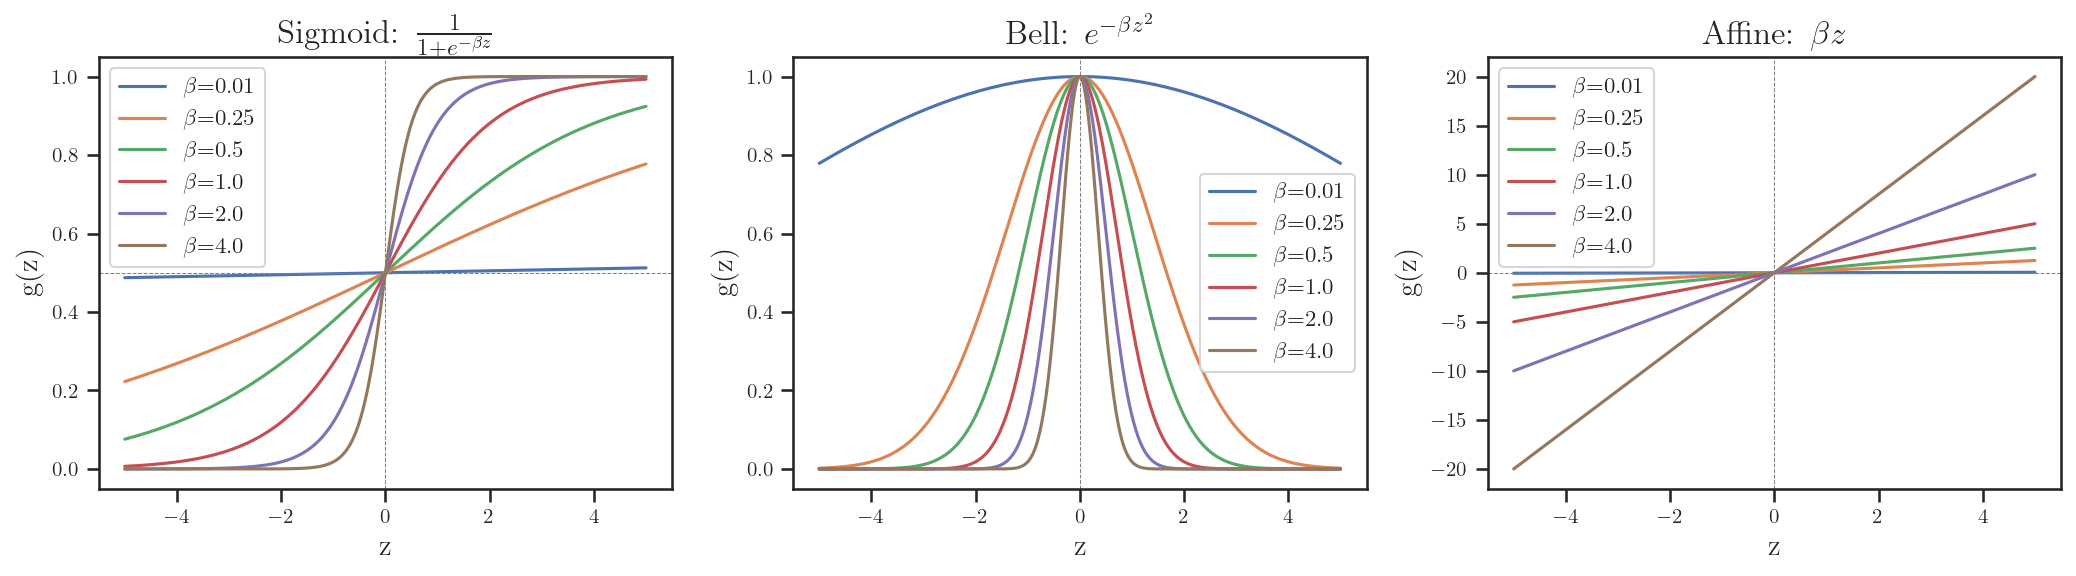

In [51]:
# Filter functions g(z; β)

def g_sigmoid(z: np.ndarray, beta: float) -> np.ndarray:
    """Sigmoid: 1 / (1 + exp(-β * z)) — increasing, bounded [0, 1]."""
    return 1.0 / (1.0 + np.exp(-beta * z))

def g_bell(z: np.ndarray, beta: float) -> np.ndarray:
    """Bell (Gaussian): exp(-β * z²) — symmetric, peaked at 0, bounded [0, 1]."""
    return np.exp(-beta * z ** 2)

def g_affine(z: np.ndarray, beta: float) -> np.ndarray:
    """Affine: β * z — linear scaling."""
    return beta * z

# Visualize the filter functions
z_vals = np.linspace(-5, 5, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=150)

# Sigmoid
ax = axes[0]
for beta in [0.01, 0.25, 0.5, 1.0, 2.0, 4.0]:
    ax.plot(z_vals, g_sigmoid(z_vals, beta), label=rf"$\beta$={beta}")
ax.set_xlabel("z")
ax.set_ylabel("g(z)")
ax.set_title(r"Sigmoid: $\frac{1}{1 + e^{-\beta z}}$")
ax.legend()
ax.axhline(0.5, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")

# Bell
ax = axes[1]
for beta in [0.01, 0.25, 0.5, 1.0, 2.0, 4.0]:
    ax.plot(z_vals, g_bell(z_vals, beta), label=rf"$\beta$={beta}")
ax.set_xlabel("z")
ax.set_ylabel("g(z)")
ax.set_title(r"Bell: $e^{-\beta z^2}$")
ax.legend()
ax.axvline(0, color="gray", lw=0.5, ls="--")

# Affine
ax = axes[2]
for beta in [0.01, 0.25, 0.5, 1.0, 2.0, 4.0]:
    ax.plot(z_vals, g_affine(z_vals, beta), label=rf"$\beta$={beta}")
ax.set_xlabel("z")
ax.set_ylabel("g(z)")
ax.set_title(r"Affine: $\beta z$")
ax.legend()
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")

fig.tight_layout()
plt.show()

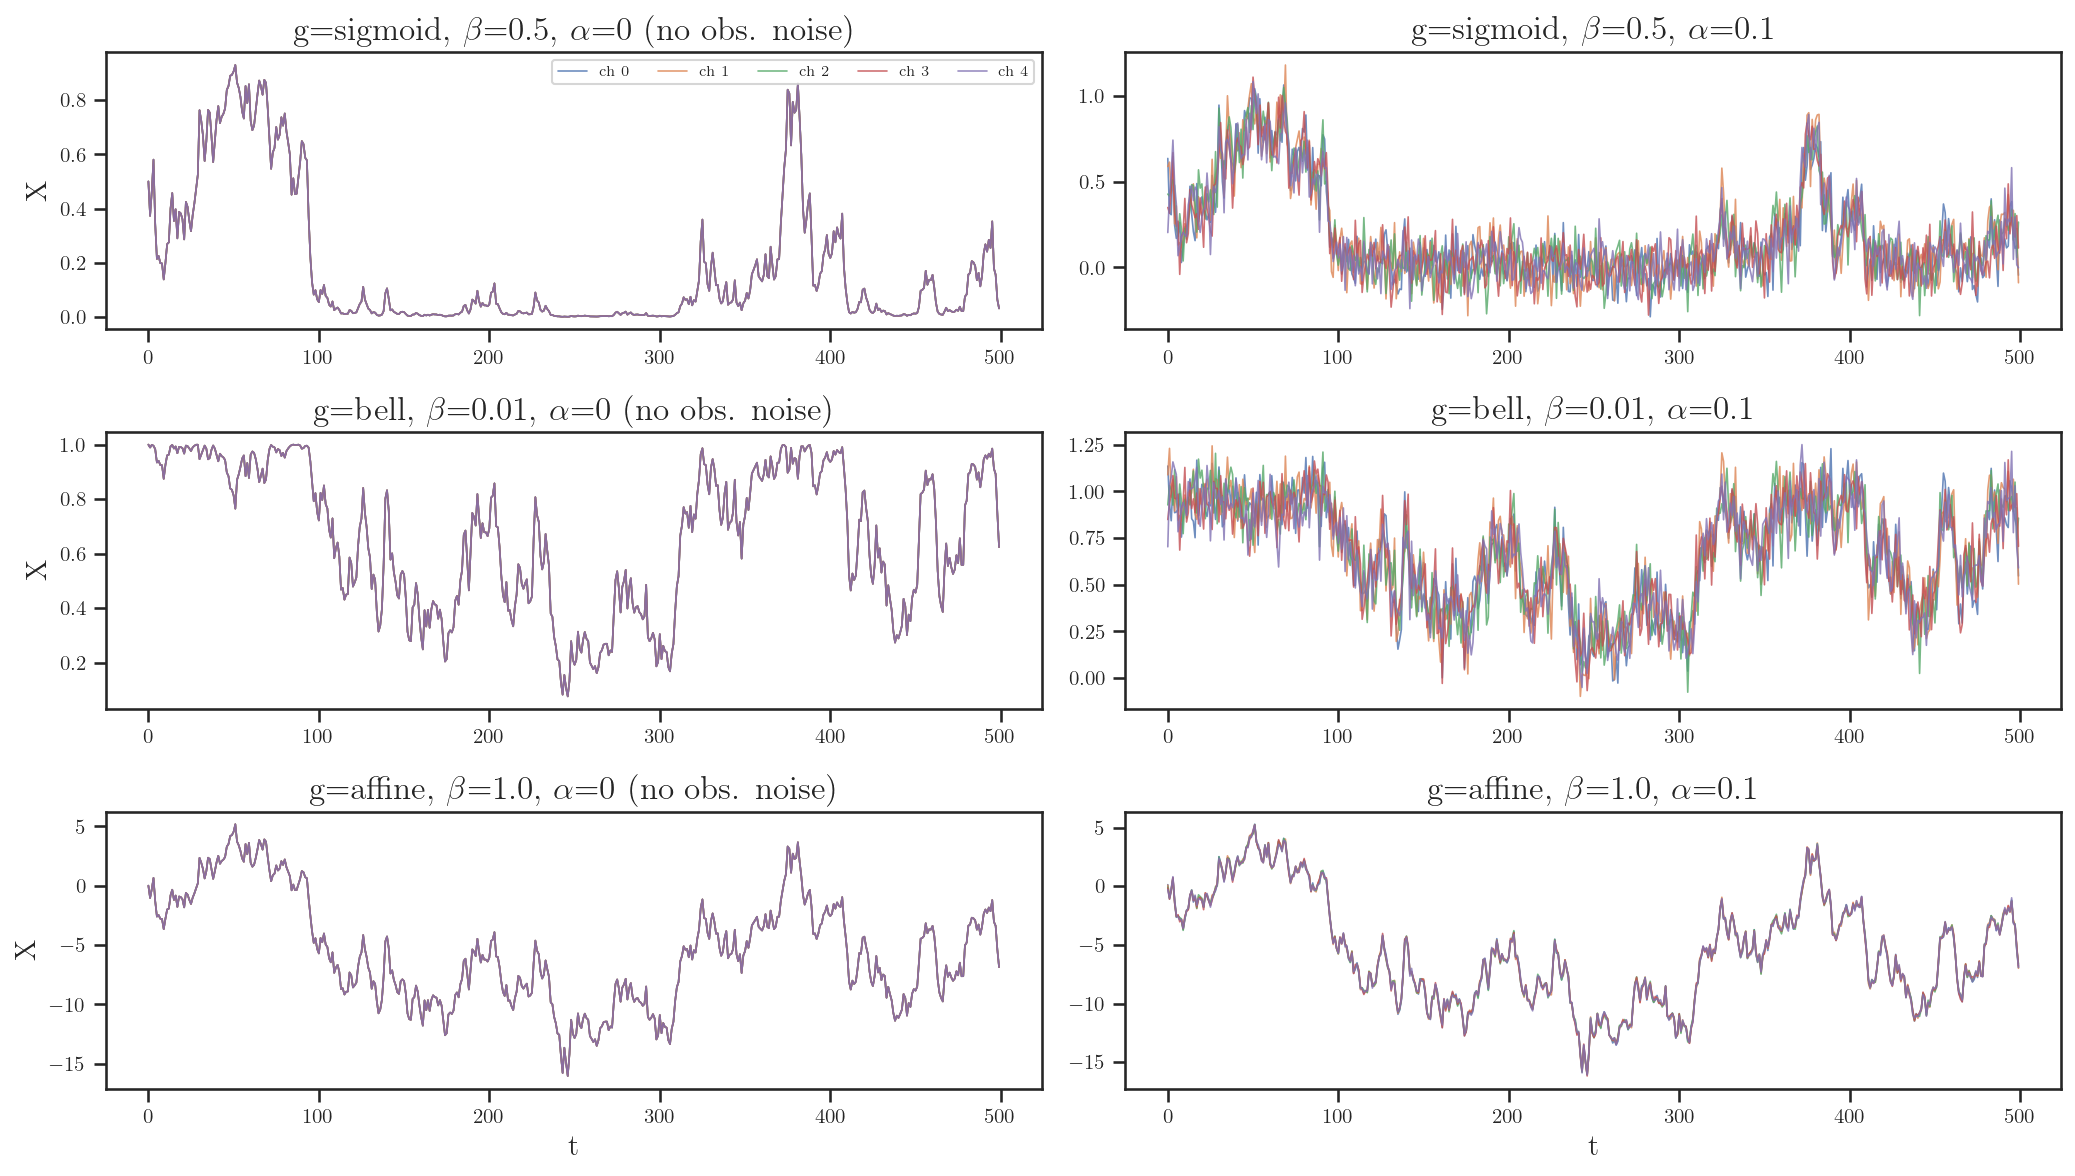

In [50]:
# Demo: generate_mts_master with different filter functions

M, T = 5, 500
seed = 42

fig, axes = plt.subplots(3, 2, figsize=(14, 8), dpi=150)

for row, (g_name, beta) in enumerate([("sigmoid", 0.5), ("bell", 0.01), ("affine", 1.0)]):
    # Without observational noise
    X_clean = generate_mts_master(M=M, T=T, g=g_name, beta=beta, alpha=0.0, seed=seed, zscore=False)
    # With observational noise
    X_noisy = generate_mts_master(M=M, T=T, g=g_name, beta=beta, alpha=0.1, seed=seed, zscore=False)
    
    ax_clean, ax_noisy = axes[row, 0], axes[row, 1]
    
    for i in range(M):
        ax_clean.plot(X_clean[:, i], lw=0.8, alpha=0.8, label=f"ch {i}")
        ax_noisy.plot(X_noisy[:, i], lw=0.8, alpha=0.8)
    
    ax_clean.set_title(rf"g={g_name}, $\beta$={beta}, $\alpha$=0 (no obs. noise)")
    ax_noisy.set_title(rf"g={g_name}, $\beta$={beta}, $\alpha$=0.1")
    ax_clean.set_ylabel("X")
    
axes[-1, 0].set_xlabel("t")
axes[-1, 1].set_xlabel("t")
axes[0, 0].legend(loc="upper right", fontsize=7, ncol=5)

fig.tight_layout()
plt.show()

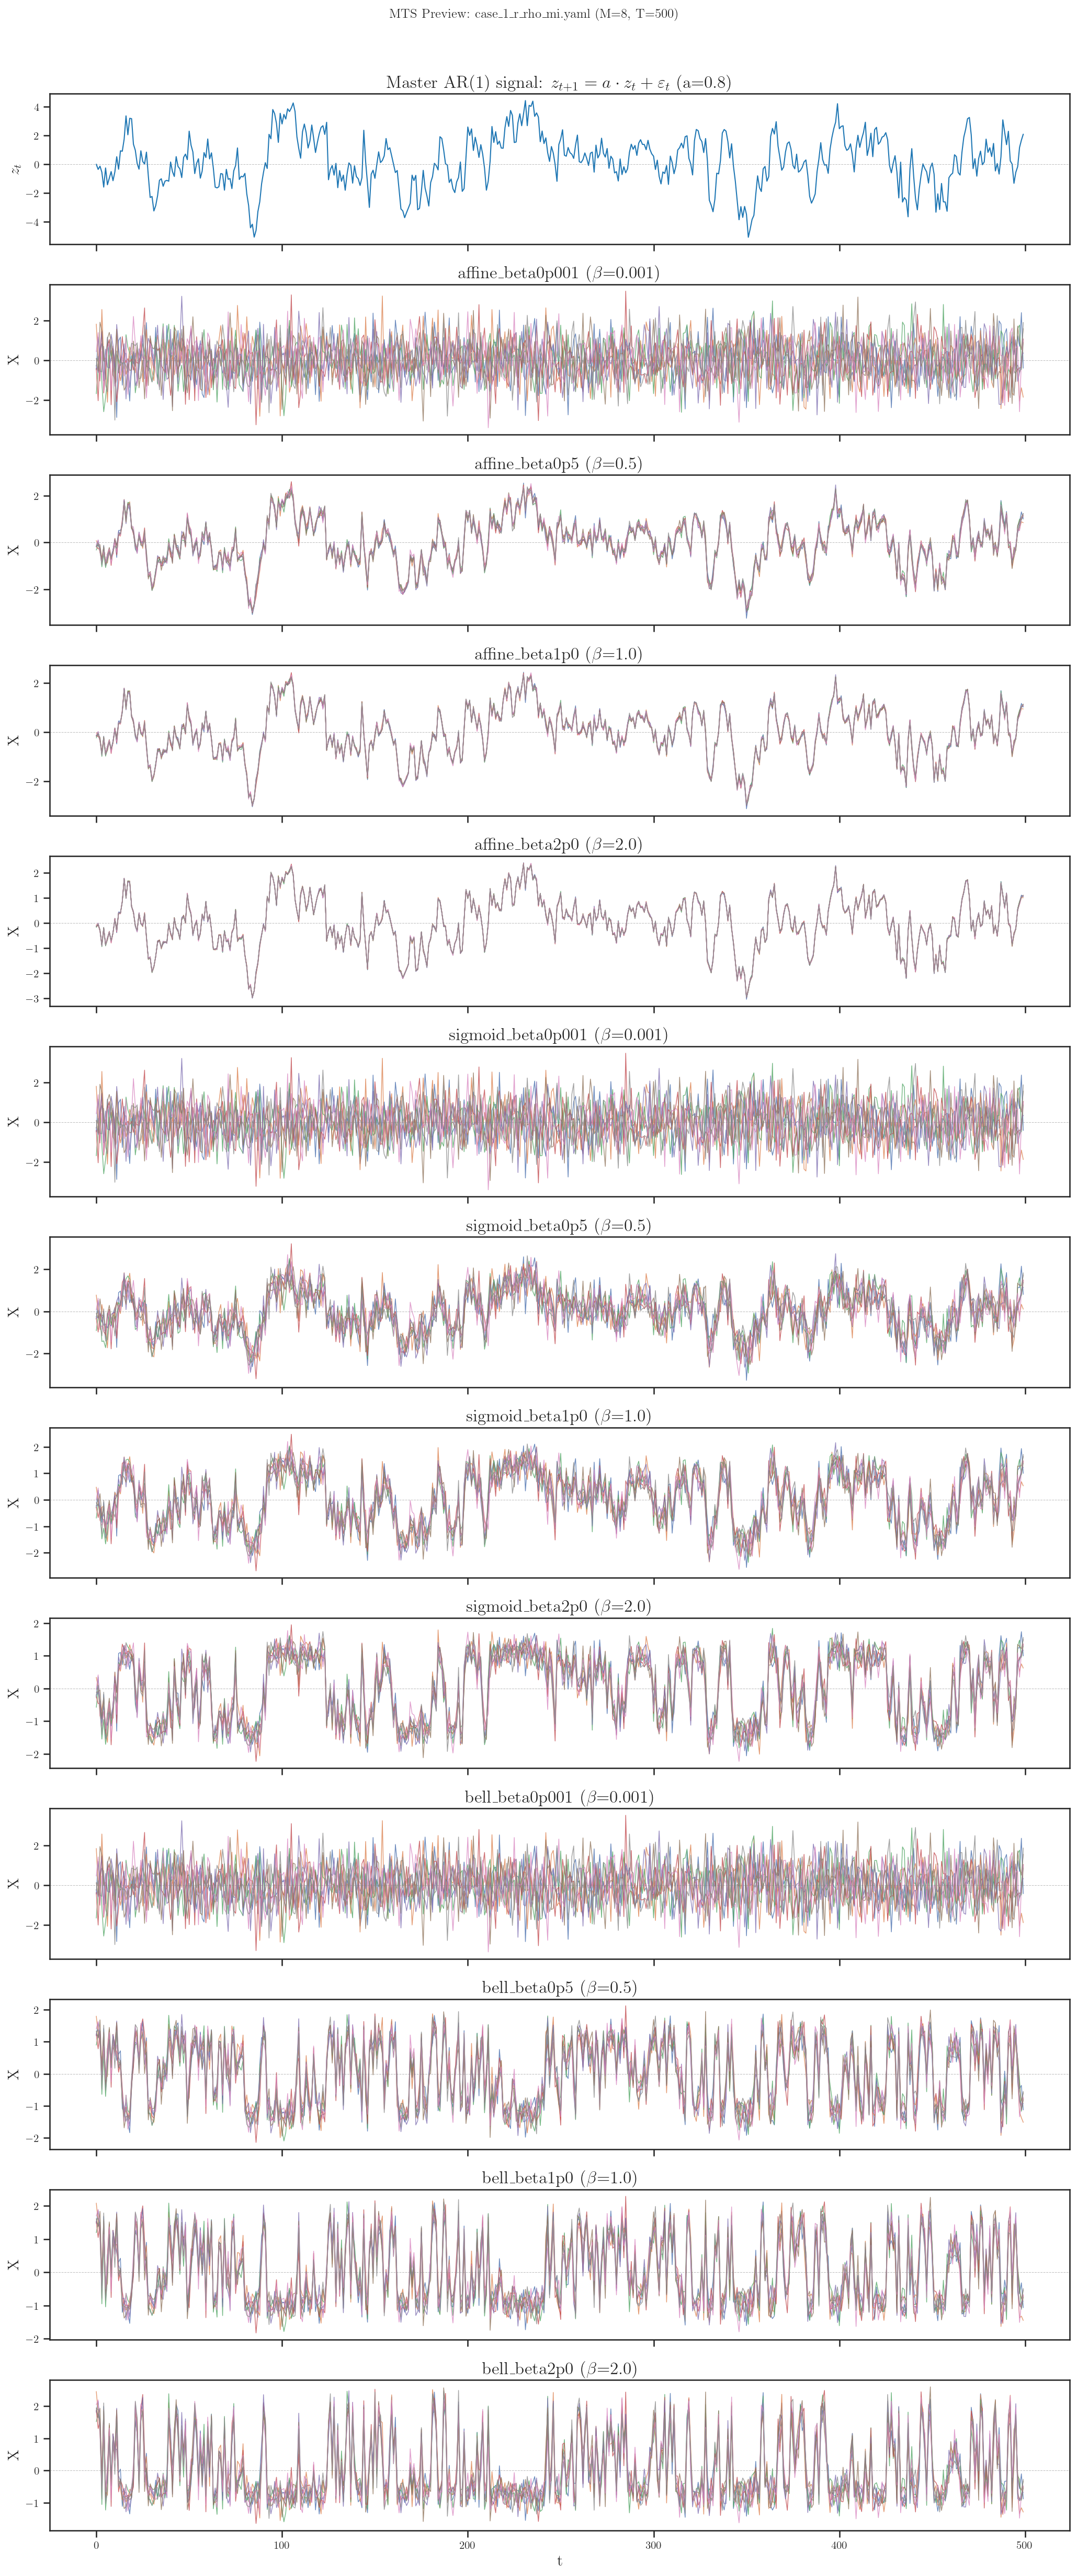

In [96]:
# Preview MTS from case_1_r_rho_mi.yaml config
from src.utils import load_yaml
from src.generate import generate_series

config_path = Path("configs/generate/case_1_r_rho_mi.yaml")
cfg = load_yaml(config_path)

# Sample parameters
M, T = 8, 500
seed = cfg.get("rng_seed", 110305)

# Get a and noise_std from first MTS class (should be same for all)
first_class_params = cfg["mts_classes"][0]["base_params"]
a = first_class_params.get("a", 1.0)
noise_std = first_class_params.get("noise_std", 1.0)

# Generate the shared master AR(1) signal
rng = np.random.default_rng(seed)
z_master = np.zeros(T)
for t in range(1, T):
    z_master[t] = a * z_master[t-1] + rng.normal(0, noise_std)

mts_classes = cfg["mts_classes"]
n_classes = len(mts_classes)

# 1 row for master + n_classes rows for each MTS
fig, axes = plt.subplots(n_classes + 1, 1, figsize=(14, 2.5 * (n_classes + 1)), dpi=150, sharex=True)

# Plot master signal
ax_master = axes[0]
ax_master.plot(z_master, lw=1.0, color="#1f77b4")
ax_master.set_ylabel(r"$z_t$")
ax_master.set_title(rf"Master AR(1) signal: $z_{{t+1}} = a \cdot z_t + \varepsilon_t$ (a={a})")
ax_master.axhline(0, color="gray", lw=0.5, ls="--", alpha=0.5)

# Plot each MTS class
for i, mts_class in enumerate(mts_classes):
    name = mts_class["name"]
    generator = mts_class["generator"]
    params = mts_class["base_params"].copy()
    
    # Generate the time series (uses same seed, so same master signal internally)
    X = generate_series(generator, seed=seed, M=M, T=T, **params)
    
    ax = axes[i + 1]
    for ch in range(M):
        ax.plot(X[:, ch], lw=0.7, alpha=0.8)
    
    beta = params.get("beta", "?")
    ax.set_ylabel("X")
    ax.set_title(rf"{name} ($\beta$={beta})")
    ax.axhline(0, color="gray", lw=0.5, ls="--", alpha=0.5)

axes[-1].set_xlabel("t")
fig.suptitle(f"MTS Preview: {config_path.name} (M={M}, T={T})", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

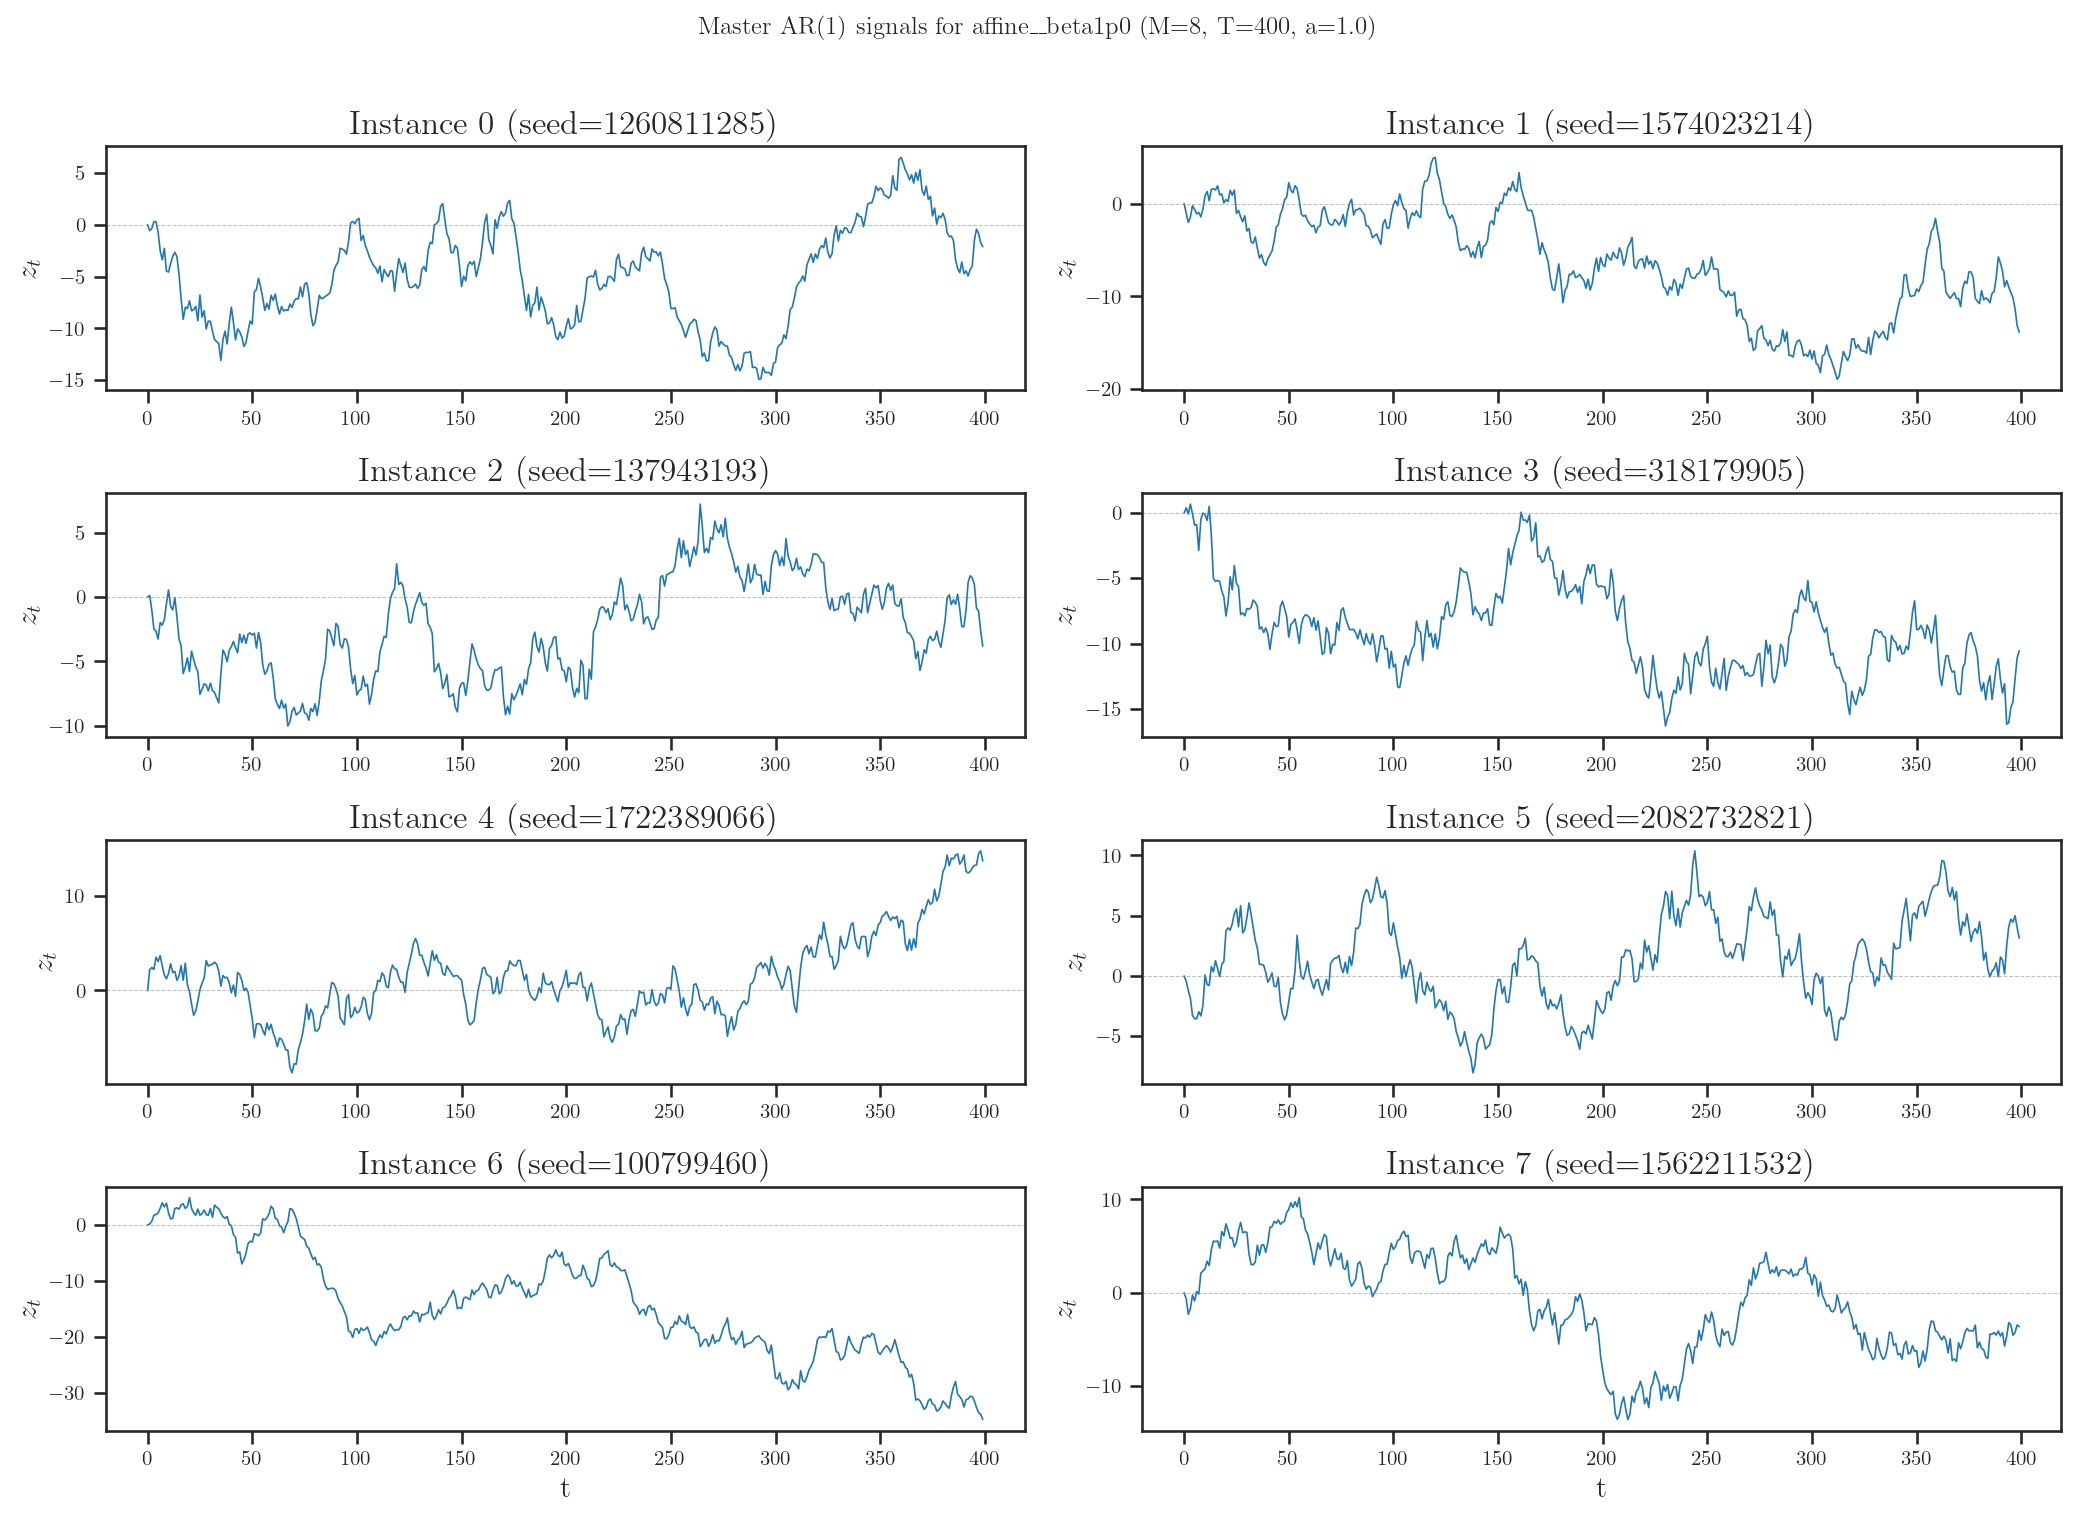


Each instance uses a UNIQUE seed → DIFFERENT master signal!
But all variants (beta values) of the SAME class+M+T+instance share the SAME master signal.


In [ ]:
import hashlib
from src.utils import load_yaml

config_path = Path("configs/generate/case_1_r_rho_mi.yaml")
cfg = load_yaml(config_path)

base_seed = cfg.get("rng_seed", 110305)
a = cfg["mts_classes"][0]["base_params"].get("a", 1.0)
noise_std = cfg["mts_classes"][0]["base_params"].get("noise_std", 1.0)

def derive_dataset_seed(base_seed, mts_class, variant_slug, M, T, instance):
    """Replicate _derive_dataset_seed from mapping.py"""
    components = [
        str(base_seed),
        "data/master_signal",  # base_output_dir from config
        mts_class,
        f"{mts_class}__{variant_slug}__M{M}_T{T}_i{instance}",
        variant_slug,
        f"M{M}",
        f"T{T}",
        f"I{instance}",
    ]
    payload = "|".join(components).encode("utf-8")
    digest = hashlib.blake2s(payload, digest_size=8).digest()
    seed = int.from_bytes(digest, "big") % 2147483647
    return seed if seed != 0 else 2147483647

def generate_master_signal(seed, T, a, noise_std):
    """Generate AR(1) master signal with given seed."""
    rng = np.random.default_rng(seed)
    z = np.zeros(T)
    for t in range(1, T):
        z[t] = a * z[t-1] + rng.normal(0, noise_std)
    return z

# Example: Compare master signals for different instances of the same class+variant
M, T = 8, 400
mts_class = "affine"
variant = "beta1p0"

fig, axes = plt.subplots(4, 2, figsize=(14, 10), dpi=150)
axes = axes.flatten()

# Plot master signals for instances 0-7
for i in range(8):
    seed = derive_dataset_seed(base_seed, mts_class, variant, M, T, instance=i)
    z = generate_master_signal(seed, T, a, noise_std)
    
    ax = axes[i]
    ax.plot(z, lw=0.8, color="#1f77b4")
    ax.set_title(f"Instance {i} (seed={seed})")
    ax.axhline(0, color="gray", lw=0.5, ls="--", alpha=0.5)
    ax.set_ylabel(r"$z_t$")
    
axes[-2].set_xlabel("t")
axes[-1].set_xlabel("t")
fig.suptitle(rf"Master AR(1) signals for {mts_class}__{variant} (M={M}, T={T}, a={a})", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()
